<a href="https://colab.research.google.com/github/Jef-H/gage_against_the_machine/blob/develop/GageAgainstMachine_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gage Against The Machine 🌊🤖
by **J. Hinton**  


---




Welcome to the **Gage Against The Machine** project! 🚀

In this notebook, we are doing Exploratory Data analysis to be upstream for a  supervised regression model.  This model will take features like **temperature, discharge rate, gage height, and nitrate levels** to predict turbidity — and ultimately help us understand how these variables interact in water systems.

We’re using data from the **USGS Turkey River Station** (Site 05412500)
https://waterdata.usgs.gov/monitoring-location/05412500/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false


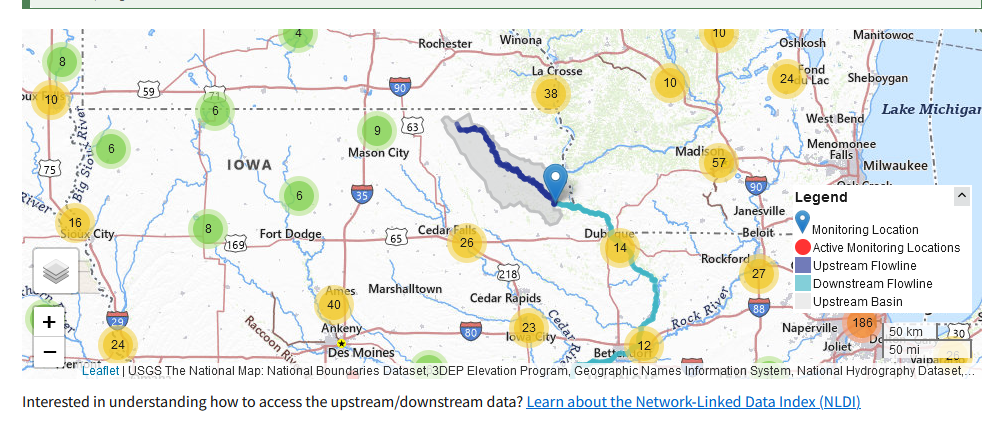

Grab your virtual waders, it’s time to get to work! 🏞️🌟

## Dataset Columns

The dataset contains several key columns, each representing a different aspect of water quality and environmental conditions. Below is a breakdown of the columns and what they represent:

| **Column Name**           | **Description**                                                                                 |
|---------------------------|-------------------------------------------------------------------------------------------------|
| `timestamp`               | The timestamp when the data was recorded (in `YYYY-MM-DD HH:MM` format).                        |
| `turbidity_fbru`          | Turbidity (water clarity) measured in **unfiltered monochrome near infra-red LED light**.       |
| `phosphorus_mg_L`         | Phosphorus concentration in the water, measured in **milligrams per liter** as phosphorus.       |
| `discharge_cfs`           | The **discharge rate** of water (cubic feet per second).                                        |
| `gage_height_ft`          | **Gage height** (in feet), representing the water level at the measurement site.                |
| `nitrate_mg_L`            | **Nitrate plus nitrite** concentration in the water, measured in **milligrams per liter** as nitrogen. |
| `temp_C`                  | The **temperature** of the water (in degrees Celsius).                                          |

---


In [18]:
import pandas as pd

# Define the URL of the dataset
url = "https://github.com/Jef-H/gage_against_the_machine/blob/develop/usgs_station_data_05412500.txt?raw=true"

# Read the file, skipping metadata and correctly handling headers
df = pd.read_csv(
    url,
    sep="\t",
    comment="#",  # Skip metadata lines
    skiprows=34,  # Skip extra format row
    na_values=["", " "],  # Treat empty values as NaN
)

df.rename(columns={
    "datetime": "timestamp",
    "251895_72213": "turbidity_fbru",
    "268036_00665": "phosphorus_mg_L",
    "43604_00060": "discharge_cfs",
    "43606_00065": "gage_height_ft",
    "43610_99133": "nitrate_mg_L",
    "43611_00010": "temp_C"
}
, inplace=True)


# Display first few rows
print(df.head())

  agency_cd   site_no         timestamp tz_cd turbidity_fbru 251895_72213_cd  \
0        5s       15s               20d    6s            14n             10s   
1      USGS  05412500  2020-01-01 00:00   CST            NaN             NaN   
2      USGS  05412500  2020-01-01 00:15   CST            NaN             NaN   
3      USGS  05412500  2020-01-01 00:30   CST            NaN             NaN   
4      USGS  05412500  2020-01-01 00:45   CST            NaN             NaN   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
0             14n             10s           14n            10s            14n   
1             NaN             NaN          2160              A           8.61   
2             NaN             NaN          2160              A           8.61   
3             NaN             NaN          2150              A           8.60   
4             NaN             NaN          2160              A           8.61   

  43606_00065_cd nitrate_mg_L 43

<ipython-input-18-a06f10e3ae0f>:7: DtypeWarning: Columns (1,4,6,7,8,10,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


The first row of data isn't quite data. Lets remove that, and then this import code could be easier to plug and play with other sites, or if we wanted to we could update our timeframe.

In [19]:
# Display the first row
print("First row:")
print(df.head(1))

# Remove the first row
df = df.iloc[1:]

# Display the new first row
print("\nFirst row after removing the original first row:")
print(df.head(1))


First row:
  agency_cd site_no timestamp tz_cd turbidity_fbru 251895_72213_cd  \
0        5s     15s       20d    6s            14n             10s   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
0             14n             10s           14n            10s            14n   

  43606_00065_cd nitrate_mg_L 43610_99133_cd temp_C 43611_00010_cd  
0            10s          14n            10s    14n            10s  

First row after removing the original first row:
  agency_cd   site_no         timestamp tz_cd turbidity_fbru 251895_72213_cd  \
1      USGS  05412500  2020-01-01 00:00   CST            NaN             NaN   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
1             NaN             NaN          2160              A           8.61   

  43606_00065_cd nitrate_mg_L 43610_99133_cd temp_C 43611_00010_cd  
1              A          NaN            NaN    NaN            NaN  


manually deleted this data format line that's mixed in with the data.

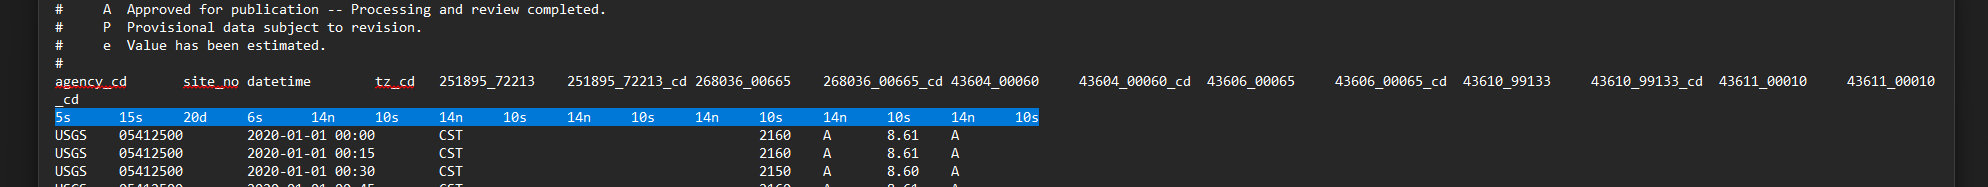

In [20]:
print(df.shape)

(180878, 16)


In [21]:
print(df.dtypes)

agency_cd          object
site_no            object
timestamp          object
tz_cd              object
turbidity_fbru     object
251895_72213_cd    object
phosphorus_mg_L    object
268036_00665_cd    object
discharge_cfs      object
43604_00060_cd     object
gage_height_ft     object
43606_00065_cd     object
nitrate_mg_L       object
43610_99133_cd     object
temp_C             object
43611_00010_cd     object
dtype: object


In [22]:
# Convert the relevant columns to numeric, coercing errors to NaN
numeric_columns = [
    'turbidity_fbru', 'phosphorus_mg_L', 'discharge_cfs',
    'gage_height_ft', 'nitrate_mg_L', 'temp_C'
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [23]:
print(df.describe())

       turbidity_fbru  phosphorus_mg_L  discharge_cfs  gage_height_ft  \
count   102022.000000     58026.000000  150921.000000   176119.000000   
mean        55.363657         0.161996    1364.273779        7.432807   
std        157.682264         0.206922    1607.354541        1.600459   
min          1.900000         0.026400     121.000000        5.220000   
25%          8.500000         0.064000     489.000000        6.430000   
50%         16.600000         0.101000     879.000000        7.110000   
75%         40.100000         0.178000    1690.000000        7.990000   
max       3570.000000         3.130000   23000.000000       23.390000   

        nitrate_mg_L        temp_C  
count  104865.000000  65460.000000  
mean        6.159164     12.643818  
std         3.078894      8.675578  
min         0.400000      0.000000  
25%         4.000000      4.800000  
50%         5.400000     12.600000  
75%         7.400000     20.500000  
max        20.000000     32.900000  


# Data gaps

There are going to be gaps in the data because every year in Iowa it gets cold and the water freezes so we'll see periodic gaps during winter months.

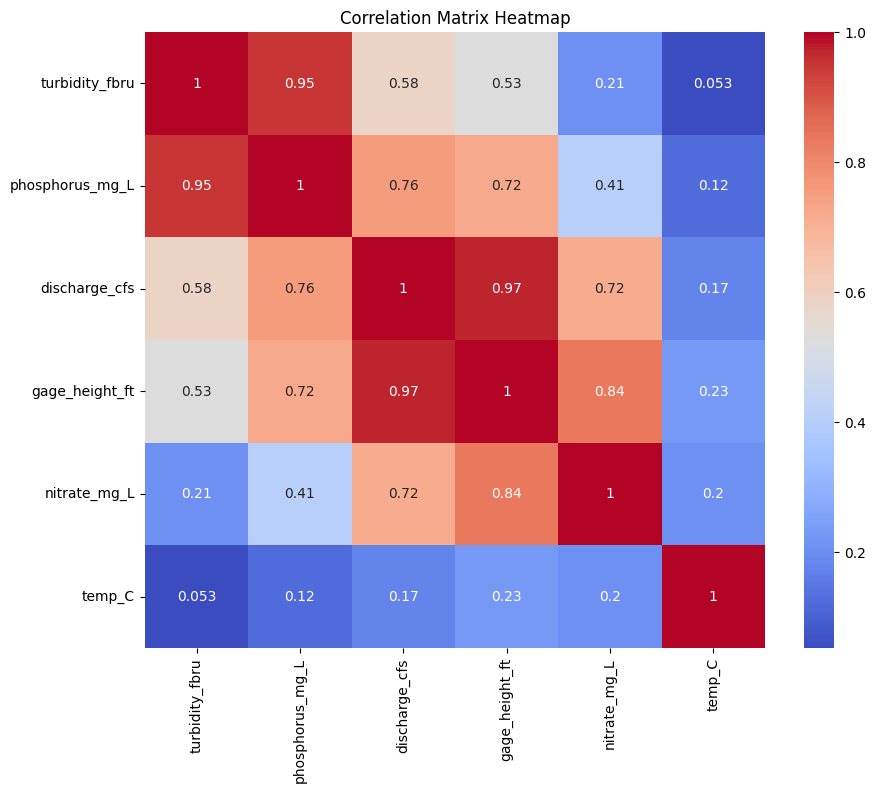

In [33]:
# Step 1: Identify non-numeric values in the numeric columns
numeric_columns = [
    'turbidity_fbru', 'phosphorus_mg_L', 'discharge_cfs',
    'gage_height_ft', 'nitrate_mg_L', 'temp_C'
]

# Step 2: Convert the numeric columns to numeric, coercing errors into NaN
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Step 3: Remove any rows with NaN values in the numeric columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 4: Check the correlation matrix (exclude non-numeric columns)
# Ensure to exclude any remaining non-numeric columns from the correlation matrix
correlation_matrix = df_cleaned[numeric_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


The correlation matrix suggests strong relationships between several water quality parameters. Turbidity and phosphorus concentration have a high correlation (0.95), indicating that as turbidity increases, phosphorus levels rise. Discharge and gage height show an extremely strong correlation (0.97), which is expected since higher water flow often results in increased water level. Nitrate concentration correlates strongly with discharge (0.72) and gage height (0.83), suggesting that nitrate levels increase with higher water flow, possibly from runoff sources. Temperature, however, has weak correlations with all other variables.

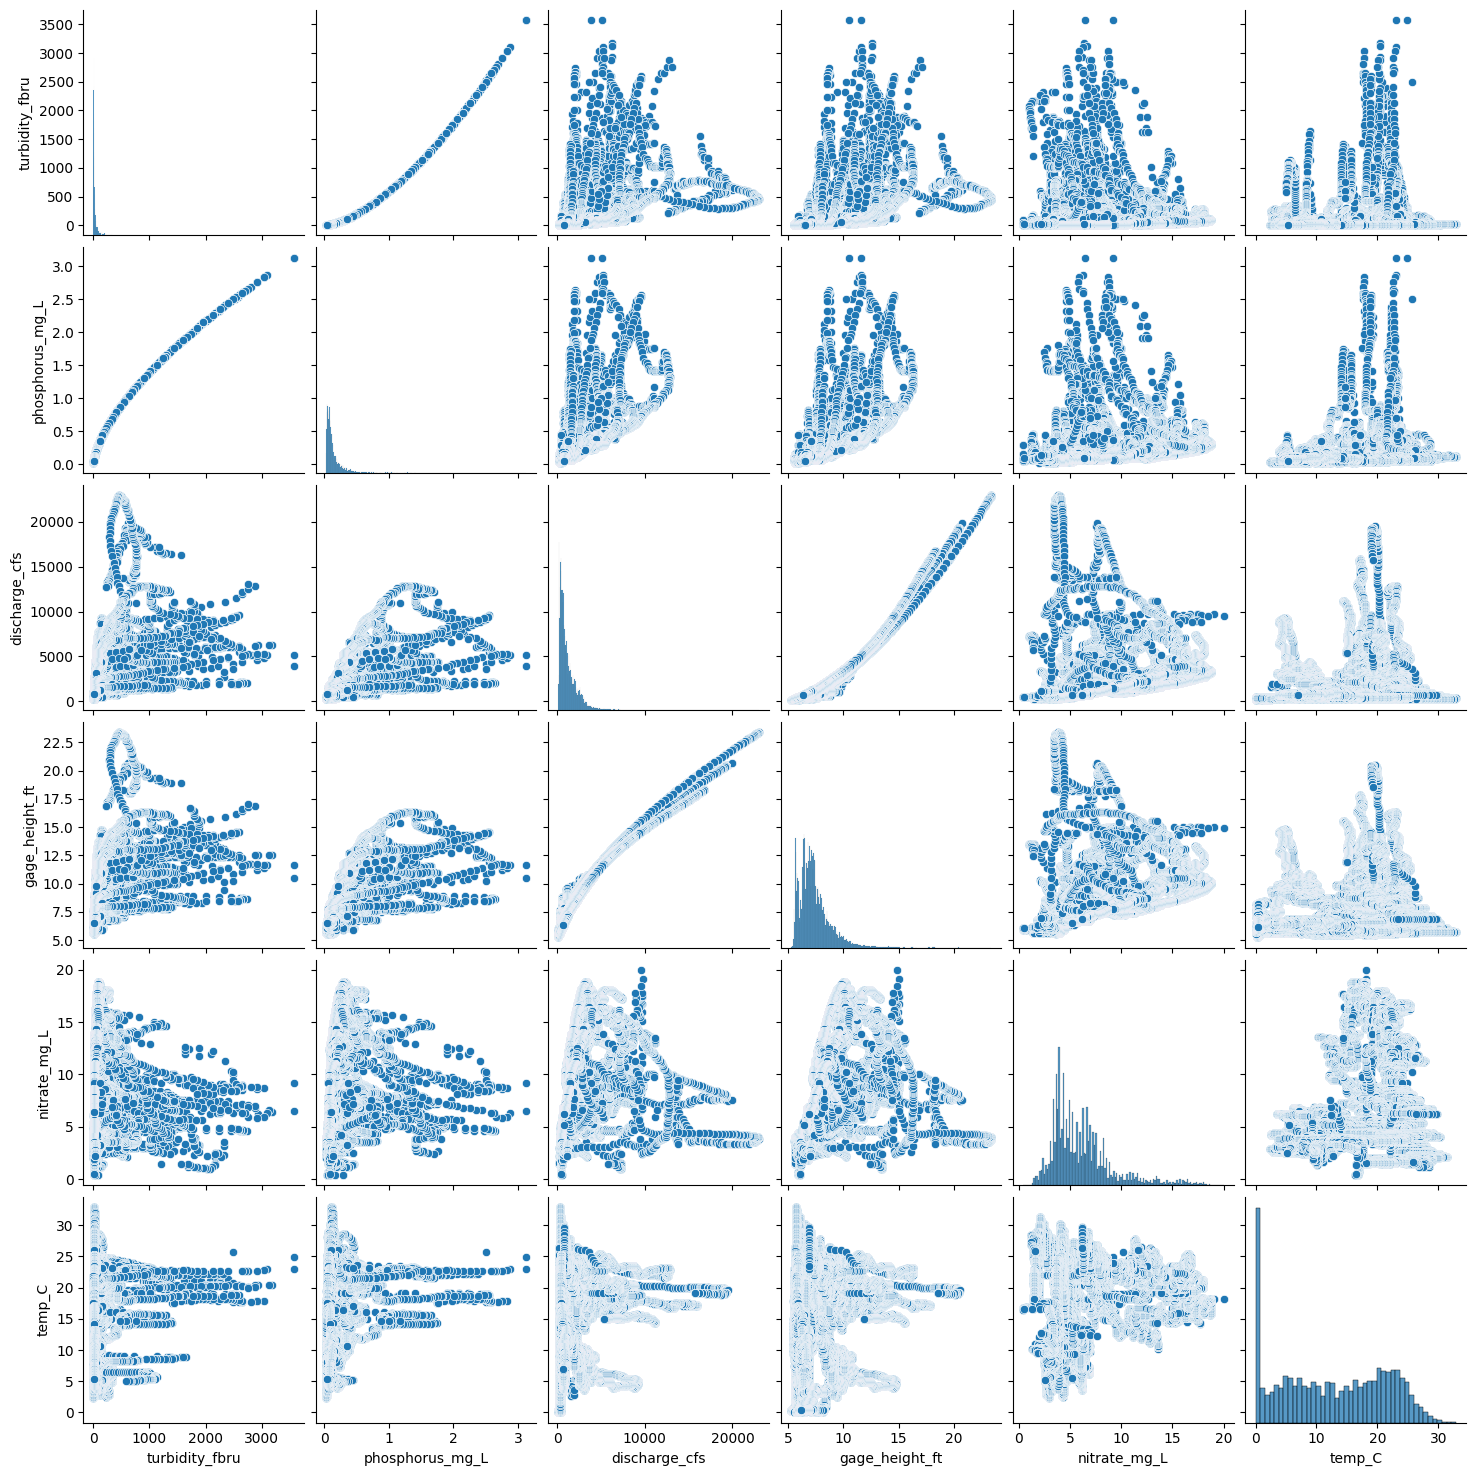

In [25]:
# Pair plot
sns.pairplot(df)
plt.show()

The SNS pair plot is showcasing similar trends to the correlation matrix. The strong correlation between discharge_cfs and gage_height_ft is depicted as their scatterplot shows a clear linear trend, suggesting that as discharge increases, water levels rise in a predictable manner. In addition to that, the relationship between phosphorus_mg_L and turbidity_fbru is tightly corellated, suggesting that phosphorus levels increase with turbidity. This is likely due to sediment-bound nutrients. The pair plot also highlights weaker correlations, such as the relationship between temperature and other variables, where the scatterplots appear more spuratic.



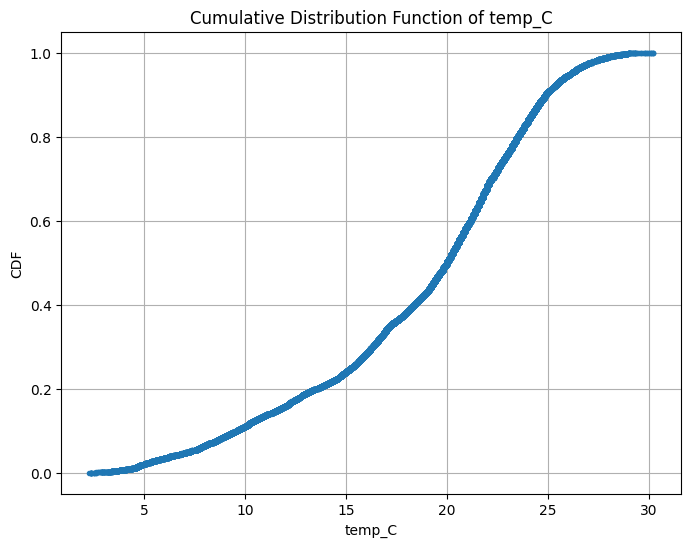

Quartiles for temp_C:
Q1 (25th percentile): 15.30
Median (50th percentile): 20.00
Q3 (75th percentile): 22.80


In [32]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the column for CDF (you can choose any numeric column)
column = 'temp_C'

# Step 1: Drop NaN values for the selected column
data = df_cleaned[column].dropna()

# Step 2: Sort the data
sorted_data = np.sort(data)

# Step 3: Calculate the CDF
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Step 4: Plot the CDF
plt.figure(figsize=(8, 6))
plt.plot(sorted_data, cdf, marker='.', linestyle='none')
plt.title(f'Cumulative Distribution Function of {column}')
plt.xlabel(column)
plt.ylabel('CDF')
plt.grid(True)
plt.show()

# Compute Quartiles
q1 = np.percentile(sorted_data, 25)
q2 = np.percentile(sorted_data, 50)  # Median
q3 = np.percentile(sorted_data, 75)

# Print Quartiles
print(f"Quartiles for {column}:")
print(f"Q1 (25th percentile): {q1:.2f}")
print(f"Median (50th percentile): {q2:.2f}")
print(f"Q3 (75th percentile): {q3:.2f}")

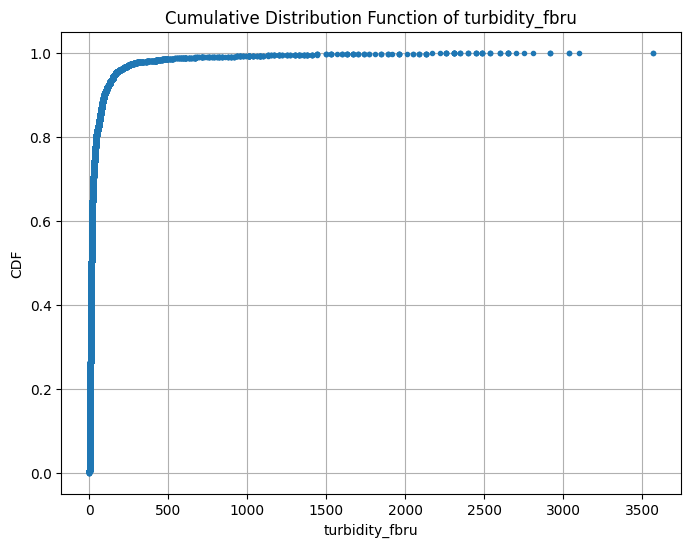

In [27]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the column for CDF (you can choose any numeric column)
column = 'turbidity_fbru'

# Step 1: Drop NaN values for the selected column
data = df_cleaned[column].dropna()

# Step 2: Sort the data
sorted_data = np.sort(data)

# Step 3: Calculate the CDF
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Step 4: Plot the CDF
plt.figure(figsize=(8, 6))
plt.plot(sorted_data, cdf, marker='.', linestyle='none')
plt.title(f'Cumulative Distribution Function of {column}')
plt.xlabel(column)
plt.ylabel('CDF')
plt.grid(True)
plt.show()

## Conclusion: Key Insights from Exploratory Data Analysis

Several key takeaways:

1. **Missing Data**: There are gaps in turbidity and phosphorus measurements, which may impact model performance. Data imputation or removal of incomplete records may be necessary. Alot of these gaps are due to winter temperatures.

2. **Feature Relationships**:  
   - **Discharge (cfs) and Gage Height (ft)** show a strong correlation, which is expected as higher discharge leads to increased water levels.  
   - **Nitrate Levels (mg/L) and Phosphorus (mg/L)** exhibit fluctuations that might be linked to seasonal changes or upstream activities.  
   - **Turbidity appears to vary with discharge**,  storm events or seasonal flows may play a role in sediment transport.  

3. **Potential Model Predictors**:  
   - Discharge rate, gage height, and nitrate levels are looking like they're going to be strong features for predicting turbidity.  

4. **Data Cleaning Needs**:  
   - Standardizing timestamps and handling missing values will be important for model training.  
   - Verifying outliers in discharge and nutrient levels to determine whether they represent measurement errors or true anomalies.  

Further analysis will focus on feature selection and addressing data quality issues.


